# Przetwarzanie szeregów czasowych z Pandas

### Datetime

In [29]:
from datetime import datetime

now = datetime.now()
now

datetime.datetime(2026, 3, 8, 20, 31, 7, 9253)

In [30]:
#rok, miesiąc, dzień
now.year, now.month, now.day

(2026, 3, 8)

In [39]:
# różnica pomiędzy datami - okres
delta = datetime(2026, 1, 2) - datetime(2025, 7, 12, 8, 50)
delta

datetime.timedelta(days=173, seconds=54600)

In [40]:
delta.days

173

In [41]:
delta.seconds

54600

### Formatowanie daty

In [42]:
stamp = datetime(2026, 8, 3)
str(stamp)

'2026-08-03 00:00:00'

In [43]:
stamp.strftime("%Y-%m-%d")

'2026-08-03'

In [44]:
stamp.strftime("%Y-%d-%m")

'2026-03-08'

In [45]:
stamp.strftime("%Y-%d-%m %H:%M:%S")

'2026-03-08 00:00:00'

In [49]:
# dzień tygodnia
stamp.strftime("%A")

'Monday'

### Wykorzystanie Series i datetime jako narzedzi do przetwarzania szeregów czasowych

In [7]:
import pandas as pd
import numpy as np

dates = [datetime(2026, 1, 2), datetime(2026, 1, 3),
         datetime(2026, 1, 4), datetime(2026, 1, 5)]
ts = pd.Series(np.random.standard_normal(4), index=dates)
ts

2026-01-02    1.352917
2026-01-03    0.886429
2026-01-04   -2.001637
2026-01-05   -0.371843
dtype: float64

In [50]:
ts.index

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05'],
              dtype='datetime64[ns]', freq='D')

In [9]:
# parametry statystyczne
ts.describe()

count    4.000000
mean    -0.033533
std      1.500718
min     -2.001637
25%     -0.779291
50%      0.257293
75%      1.003051
max      1.352917
dtype: float64

In [8]:
# operacje matematyczne na szeregach czasowych
ts + ts

2026-01-02    2.705834
2026-01-03    1.772859
2026-01-04   -4.003275
2026-01-05   -0.743685
dtype: float64

In [10]:
# odwołanie się do próbki
ts['2026-01-04']

np.float64(-2.0016373096603974)

In [11]:
# odwołanie się do zakresu
ts['2026-01-02':'2026-01-03']

2026-01-02    1.352917
2026-01-03    0.886429
dtype: float64

In [23]:
# próbkowanie w dół
ts.resample('YE').mean()

2026-12-31   -0.033533
Freq: YE-DEC, dtype: float64

In [51]:
# odwołanie się do wielu data jednocześnie
ts['2026-01']

2026-01-01   -0.713615
2026-01-02    0.397681
2026-01-03   -2.310050
2026-01-04   -0.760634
2026-01-05    0.005969
Freq: D, dtype: float64

In [60]:
# przesunięcie
ts.shift(3)

2026-01-01         NaN
2026-01-02         NaN
2026-01-03         NaN
2026-01-04   -0.713615
2026-01-05    0.397681
Freq: D, dtype: float64

In [61]:
# przesunięcie
ts.shift(-3)

2026-01-01   -0.760634
2026-01-02    0.005969
2026-01-03         NaN
2026-01-04         NaN
2026-01-05         NaN
Freq: D, dtype: float64

In [52]:
index = pd.date_range("2027-04-01", "2027-06-01")
index

DatetimeIndex(['2027-04-01', '2027-04-02', '2027-04-03', '2027-04-04',
               '2027-04-05', '2027-04-06', '2027-04-07', '2027-04-08',
               '2027-04-09', '2027-04-10', '2027-04-11', '2027-04-12',
               '2027-04-13', '2027-04-14', '2027-04-15', '2027-04-16',
               '2027-04-17', '2027-04-18', '2027-04-19', '2027-04-20',
               '2027-04-21', '2027-04-22', '2027-04-23', '2027-04-24',
               '2027-04-25', '2027-04-26', '2027-04-27', '2027-04-28',
               '2027-04-29', '2027-04-30', '2027-05-01', '2027-05-02',
               '2027-05-03', '2027-05-04', '2027-05-05', '2027-05-06',
               '2027-05-07', '2027-05-08', '2027-05-09', '2027-05-10',
               '2027-05-11', '2027-05-12', '2027-05-13', '2027-05-14',
               '2027-05-15', '2027-05-16', '2027-05-17', '2027-05-18',
               '2027-05-19', '2027-05-20', '2027-05-21', '2027-05-22',
               '2027-05-23', '2027-05-24', '2027-05-25', '2027-05-26',
      

In [54]:
pd.date_range(start="2027-04-01", periods=20)

DatetimeIndex(['2027-05-13', '2027-05-14', '2027-05-15', '2027-05-16',
               '2027-05-17', '2027-05-18', '2027-05-19', '2027-05-20',
               '2027-05-21', '2027-05-22', '2027-05-23', '2027-05-24',
               '2027-05-25', '2027-05-26', '2027-05-27', '2027-05-28',
               '2027-05-29', '2027-05-30', '2027-05-31', '2027-06-01'],
              dtype='datetime64[ns]', freq='D')

In [55]:
pd.date_range(end="2027-06-01", periods=20)

DatetimeIndex(['2027-05-13', '2027-05-14', '2027-05-15', '2027-05-16',
               '2027-05-17', '2027-05-18', '2027-05-19', '2027-05-20',
               '2027-05-21', '2027-05-22', '2027-05-23', '2027-05-24',
               '2027-05-25', '2027-05-26', '2027-05-27', '2027-05-28',
               '2027-05-29', '2027-05-30', '2027-05-31', '2027-06-01'],
              dtype='datetime64[ns]', freq='D')

In [58]:
# datowanie na koniec miesiąca
pd.date_range("2027-01-01", "2028-12-01", freq="BME")

DatetimeIndex(['2027-01-29', '2027-02-26', '2027-03-31', '2027-04-30',
               '2027-05-31', '2027-06-30', '2027-07-30', '2027-08-31',
               '2027-09-30', '2027-10-29', '2027-11-30', '2027-12-31',
               '2028-01-31', '2028-02-29', '2028-03-31', '2028-04-28',
               '2028-05-31', '2028-06-30', '2028-07-31', '2028-08-31',
               '2028-09-29', '2028-10-31', '2028-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [41]:
#! ipython id=43fd4a3b864347008c9e58579d1318ec
ts.shift(3, freq="D")
ts.shift(1, freq="90T")

2000-01-31 01:30:00   -0.066748
2000-02-29 01:30:00    0.838639
2000-03-31 01:30:00   -0.117388
2000-04-30 01:30:00   -0.517795
dtype: float64

In [42]:
#! ipython id=d3a295c2d66d4ee49501d8e52df4006c
from pandas.tseries.offsets import Day, MonthEnd
now = datetime(2011, 11, 17)
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

In [43]:
#! ipython id=840a4a58d2444b42b7f71aa5f69af613
now + MonthEnd()
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [44]:
#! ipython id=947ac8d4eae84bcb9abbd6250957070f
offset = MonthEnd()
offset.rollforward(now)
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

In [45]:
#! ipython id=efd27228c8f54689b2e1e476204ba317
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range("2000-01-15", periods=20, freq="4D"))
ts
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.005833
2000-02-29    0.015894
2000-03-31    0.150209
dtype: float64

In [46]:
#! ipython id=b6d6087bdfb4474f91a0cf774283f1d1
ts.resample("M").mean()

2000-01-31   -0.005833
2000-02-29    0.015894
2000-03-31    0.150209
Freq: ME, dtype: float64

In [47]:
#! ipython id=19c326a03d9a4cd783fbcc8cb5ff421c
import pytz
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [48]:
#! ipython id=81652670d9d84ed1bc65dff261cd0937
tz = pytz.timezone("America/New_York")
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

In [49]:
#! ipython id=27a1920372f0414cb335c9ac80c1a883
dates = pd.date_range("2012-03-09 09:30", periods=6)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-09 09:30:00   -0.202469
2012-03-10 09:30:00    0.050718
2012-03-11 09:30:00    0.639869
2012-03-12 09:30:00    0.597594
2012-03-13 09:30:00   -0.797246
2012-03-14 09:30:00    0.472879
Freq: D, dtype: float64

In [50]:
#! ipython id=fd6da4e7623d40babb80385bd6b80a36
print(ts.index.tz)

None


In [51]:
#! ipython id=e03db4a0b6d34d66a88f0be927424a1b
pd.date_range("2012-03-09 09:30", periods=10, tz="UTC")

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [52]:
#! ipython id=0dd2997562634b6c9161adc215855962
ts
ts_utc = ts.tz_localize("UTC")
ts_utc
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [53]:
#! ipython id=49c15434eb0c47bf950d42390118f378
ts_utc.tz_convert("America/New_York")

2012-03-09 04:30:00-05:00   -0.202469
2012-03-10 04:30:00-05:00    0.050718
2012-03-11 05:30:00-04:00    0.639869
2012-03-12 05:30:00-04:00    0.597594
2012-03-13 05:30:00-04:00   -0.797246
2012-03-14 05:30:00-04:00    0.472879
Freq: D, dtype: float64

In [54]:
#! ipython id=01e4044008b14d7f9e4990a1e66210e3
ts_eastern = ts.tz_localize("America/New_York")
ts_eastern.tz_convert("UTC")
ts_eastern.tz_convert("Europe/Berlin")

2012-03-09 15:30:00+01:00   -0.202469
2012-03-10 15:30:00+01:00    0.050718
2012-03-11 14:30:00+01:00    0.639869
2012-03-12 14:30:00+01:00    0.597594
2012-03-13 14:30:00+01:00   -0.797246
2012-03-14 14:30:00+01:00    0.472879
dtype: float64

In [55]:
#! ipython id=1dcc4db3bd4b43138c22293079cafe68
ts.index.tz_localize("Asia/Shanghai")

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

In [56]:
#! ipython id=e3618c9788f040a38fac2443dac25892
stamp = pd.Timestamp("2011-03-12 04:00")
stamp_utc = stamp.tz_localize("utc")
stamp_utc.tz_convert("America/New_York")

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [57]:
#! ipython id=8715a838b21f4789a6b58e4ceb0a56e4
stamp_moscow = pd.Timestamp("2011-03-12 04:00", tz="Europe/Moscow")
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

In [58]:
#! ipython id=0aed2bac3c41471899b081a582412f4e
stamp_utc.value
stamp_utc.tz_convert("America/New_York").value

1299902400000000000

In [59]:
#! ipython id=b778152898374964a084de3b3b63f935
stamp = pd.Timestamp("2012-03-11 01:30", tz="US/Eastern")
stamp
stamp + Hour()

Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern')

In [60]:
#! ipython id=c0d18d84985d4ede88ec95727c7fb8e9
stamp = pd.Timestamp("2012-11-04 00:30", tz="US/Eastern")
stamp
stamp + 2 * Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

In [61]:
#! ipython id=8cde92a79e444f44b5f952eabb4b7491
dates = pd.date_range("2012-03-07 09:30", periods=10, freq="B")
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts
ts1 = ts[:7].tz_localize("Europe/London")
ts2 = ts1[2:].tz_convert("Europe/Moscow")
result = ts1 + ts2
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

In [62]:
#! ipython id=bae9a7cce5cd496b8b3756412b670013
p = pd.Period("2011", freq="A-DEC")
p

Period('2011', 'Y-DEC')

In [63]:
#! ipython id=518401c31bc8419bbf28956e2c9be595
p + 5
p - 2

Period('2009', 'Y-DEC')

In [64]:
#! ipython id=e5ff985e90fe44579705c3d3cdf5e5b7
pd.Period("2014", freq="A-DEC") - p

<3 * YearEnds: month=12>

In [65]:
#! ipython id=ef000f892654403b9f476bb7e1d9bacd
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [66]:
#! ipython id=d3426c6da33b4175891f9d8d4caa4ab8
pd.Series(np.random.standard_normal(6), index=periods)

2000-01   -0.514551
2000-02   -0.559782
2000-03   -0.783408
2000-04   -1.797685
2000-05   -0.172670
2000-06    0.680215
Freq: M, dtype: float64

In [67]:
#! ipython id=47db0721ff4a4ca89bdc74daae703a55
values = ["2001Q3", "2002Q2", "2003Q1"]
index = pd.PeriodIndex(values, freq="Q-DEC")
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

In [68]:
#! ipython id=348880d80dc14062bb80c374d953f7ce
p = pd.Period("2011", freq="A-DEC")
p
p.asfreq("M", how="start")
p.asfreq("M", how="end")
p.asfreq("M")

Period('2011-12', 'M')

In [69]:
#! ipython id=669af5f271964c7cbefe3265cde35c6c
p = pd.Period("2011", freq="A-JUN")
p
p.asfreq("M", how="start")
p.asfreq("M", how="end")

Period('2011-06', 'M')

In [70]:
#! ipython id=ec04cdb713554c0fa0b4162e372b9876
p = pd.Period("Aug-2011", "M")
p.asfreq("A-JUN")

Period('2012', 'Y-JUN')

In [71]:
#! ipython id=979cb059424a48f6a887fb50fdb66adf
periods = pd.period_range("2006", "2009", freq="A-DEC")
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)
ts
ts.asfreq("M", how="start")

2006-01    1.607578
2007-01    0.200381
2008-01   -0.834068
2009-01   -0.302988
Freq: M, dtype: float64

In [72]:
#! ipython id=51ab6bd5e33e433a8786b0a3fe239dd2
ts.asfreq("B", how="end")

2006-12-29    1.607578
2007-12-31    0.200381
2008-12-31   -0.834068
2009-12-31   -0.302988
Freq: B, dtype: float64

In [73]:
#! ipython id=38b59581b62f4808a145d4b5bac7d04c
p = pd.Period("2012Q4", freq="Q-JAN")
p

Period('2012Q4', 'Q-JAN')

In [74]:
#! ipython id=03f4b2f382e84260bfccec8df35b5903
p.asfreq("D", how="start")
p.asfreq("D", how="end")

Period('2012-01-31', 'D')

In [75]:
#! ipython id=629d1fcb8b5d42329da5126f166a028f
p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60
p4pm
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

In [76]:
#! ipython id=2b671198cc014db3bf349878fab5e36a
periods = pd.period_range("2011Q3", "2012Q4", freq="Q-JAN")
ts = pd.Series(np.arange(len(periods)), index=periods)
ts
new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16
ts.index = new_periods.to_timestamp()
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

In [77]:
#! ipython id=debf05cadb0f4a94a7174e2f8859f352
dates = pd.date_range("2000-01-01", periods=3, freq="M")
ts = pd.Series(np.random.standard_normal(3), index=dates)
ts
pts = ts.to_period()
pts

2000-01    1.663261
2000-02   -0.996206
2000-03    1.521760
Freq: M, dtype: float64

In [78]:
#! ipython id=6ac8d11fe6a1408cb83be89895617dd6
dates = pd.date_range("2000-01-29", periods=6)
ts2 = pd.Series(np.random.standard_normal(6), index=dates)
ts2
ts2.to_period("M")

2000-01    0.244175
2000-01    0.423331
2000-01   -0.654040
2000-02    2.089154
2000-02   -0.060220
2000-02   -0.167933
Freq: M, dtype: float64

In [79]:
#! ipython id=de1111bbae4a4343945546f43c1af706
pts = ts2.to_period()
pts
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999999    0.244175
2000-01-30 23:59:59.999999999    0.423331
2000-01-31 23:59:59.999999999   -0.654040
2000-02-01 23:59:59.999999999    2.089154
2000-02-02 23:59:59.999999999   -0.060220
2000-02-03 23:59:59.999999999   -0.167933
Freq: D, dtype: float64

In [80]:
#! ipython id=d14658aeb9db49f090190ba82c255d4e
data = pd.read_csv("../data/macrodata.csv")
data.head(5)
data["year"]
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

In [22]:
import pandas as pd
import numpy as np

dates = pd.date_range("2026-01-01", periods=5, freq="D")
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2026-01-01   -0.713615
2026-01-02    0.397681
2026-01-03   -2.310050
2026-01-04   -0.760634
2026-01-05    0.005969
Freq: D, dtype: float64

In [23]:
ts.resample("5D").sum()

2026-01-01   -3.380649
Freq: 5D, dtype: float64

In [24]:
ts.resample("5D", closed="right").sum()

2025-12-27   -0.713615
2026-01-01   -2.667034
Freq: 5D, dtype: float64

In [25]:
ts.resample("60min").asfreq()

2026-01-01 00:00:00   -0.713615
2026-01-01 01:00:00         NaN
2026-01-01 02:00:00         NaN
2026-01-01 03:00:00         NaN
2026-01-01 04:00:00         NaN
                         ...   
2026-01-04 20:00:00         NaN
2026-01-04 21:00:00         NaN
2026-01-04 22:00:00         NaN
2026-01-04 23:00:00         NaN
2026-01-05 00:00:00    0.005969
Freq: 60min, Length: 97, dtype: float64

In [26]:
ts.resample("60min").asfreq().ffill()

2026-01-01 00:00:00   -0.713615
2026-01-01 01:00:00   -0.713615
2026-01-01 02:00:00   -0.713615
2026-01-01 03:00:00   -0.713615
2026-01-01 04:00:00   -0.713615
                         ...   
2026-01-04 20:00:00   -0.760634
2026-01-04 21:00:00   -0.760634
2026-01-04 22:00:00   -0.760634
2026-01-04 23:00:00   -0.760634
2026-01-05 00:00:00    0.005969
Freq: 60min, Length: 97, dtype: float64

In [27]:
ts.resample("60min").asfreq().ffill(limit=2)

2026-01-01 00:00:00   -0.713615
2026-01-01 01:00:00   -0.713615
2026-01-01 02:00:00   -0.713615
2026-01-01 03:00:00         NaN
2026-01-01 04:00:00         NaN
                         ...   
2026-01-04 20:00:00         NaN
2026-01-04 21:00:00         NaN
2026-01-04 22:00:00         NaN
2026-01-04 23:00:00         NaN
2026-01-05 00:00:00    0.005969
Freq: 60min, Length: 97, dtype: float64

In [86]:
#! ipython id=6587ba3145214dc8b3f50ccb40bc88b8
ts.resample("5min", closed="right", label="right").sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

In [87]:
#! ipython id=c48ee1ea64c2498e8ede907aea647016
from pandas.tseries.frequencies import to_offset
result = ts.resample("5min", closed="right", label="right").sum()
result.index = result.index + to_offset("-1s")
result

1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5min, dtype: int64

In [88]:
#! ipython id=e036e195212b453985a4bc219cd308f3
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,8,8,1,5
2000-01-01 00:05:00,6,11,2,2
2000-01-01 00:10:00,0,7,0,7


In [89]:
#! ipython id=22d7658abb234e16a56b2637142c053c
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                     index=pd.date_range("2000-01-01", periods=2,
                                         freq="W-WED"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.896431,0.927238,0.482284,-0.867130
2000-01-12,0.493841,-0.155434,1.397286,1.507055


In [90]:
#! ipython id=7a564b646cbc45d78d95f6333692fd84
df_daily = frame.resample("D").asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.896431,0.927238,0.482284,-0.867130
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.493841,-0.155434,1.397286,1.507055


In [91]:
#! ipython id=ecb1c4fc9803419b849c214cddaddae3
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.896431,0.927238,0.482284,-0.867130
2000-01-06,-0.896431,0.927238,0.482284,-0.867130
2000-01-07,-0.896431,0.927238,0.482284,-0.867130
2000-01-08,-0.896431,0.927238,0.482284,-0.867130
2000-01-09,-0.896431,0.927238,0.482284,-0.867130
2000-01-10,-0.896431,0.927238,0.482284,-0.867130
2000-01-11,-0.896431,0.927238,0.482284,-0.867130
2000-01-12,0.493841,-0.155434,1.397286,1.507055


In [92]:
#! ipython id=a84044fc3dbe4f0597b997ec51c96490
frame.resample("D").ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.896431,0.927238,0.482284,-0.867130
2000-01-06,-0.896431,0.927238,0.482284,-0.867130
2000-01-07,-0.896431,0.927238,0.482284,-0.867130
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.493841,-0.155434,1.397286,1.507055


In [93]:
#! ipython id=3f5e6bf2f6844db9ae9ac57ee806df7e
frame.resample("W-THU").ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-0.896431,0.927238,0.482284,-0.867130
2000-01-13,0.493841,-0.155434,1.397286,1.507055


In [94]:
#! ipython id=42a429ef95bc45fdb9c595f3b3ffd163
frame = pd.DataFrame(np.random.standard_normal((24, 4)),
                     index=pd.period_range("1-2000", "12-2001",
                                           freq="M"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame.head()
annual_frame = frame.resample("A-DEC").mean()
annual_frame

,Colorado,Texas,New York,Ohio
2000,0.487329,0.104466,0.020495,-0.273945
2001,0.203125,0.162429,0.056146,-0.103794


In [95]:
#! ipython id=21bc509f9fc340b6882974f3ec17e715
# Q-DEC: Quarterly, year ending in December
annual_frame.resample("Q-DEC").ffill()
annual_frame.resample("Q-DEC", convention="end").asfreq()

,Colorado,Texas,New York,Ohio
2000Q4,0.487329,0.104466,0.020495,-0.273945
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,0.203125,0.162429,0.056146,-0.103794


In [96]:
#! ipython id=9d82a3b714164b4dad4eceaeadeda604
annual_frame.resample("Q-MAR").ffill()

,Colorado,Texas,New York,Ohio
2000Q4,0.487329,0.104466,0.020495,-0.273945
2001Q1,0.487329,0.104466,0.020495,-0.273945
2001Q2,0.487329,0.104466,0.020495,-0.273945
2001Q3,0.487329,0.104466,0.020495,-0.273945
2001Q4,0.203125,0.162429,0.056146,-0.103794
2002Q1,0.203125,0.162429,0.056146,-0.103794
2002Q2,0.203125,0.162429,0.056146,-0.103794
2002Q3,0.203125,0.162429,0.056146,-0.103794


In [97]:
#! ipython id=f23204097cbd44b3a899d2cbaa35c2bd
N = 15
times = pd.date_range("2017-05-20 00:00", freq="1min", periods=N)
df = pd.DataFrame({"czas": times,
                   "wartość": np.arange(N)})
df

,czas,wartość
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


In [98]:
#! ipython id=806fd8e5d2aa413f8c990b6acebde10d
df.set_index("czas").resample("5min").count()

,wartość
czas,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


In [99]:
#! ipython id=9a28095367094308ad46b129e69586aa
df2 = pd.DataFrame({"czas": times.repeat(3),
                    "klucz": np.tile(["a", "b", "c"], N),
                    "wartość": np.arange(N * 3.)})
df2.head(7)

,czas,klucz,wartość
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


In [100]:
#! ipython id=0991852576124da587038d8939d3de61
time_key = pd.Grouper(freq="5min")

In [101]:
#! ipython id=a7c8d07161384a4385a4d82fffa4e7ae
resampled = (df2.set_index("czas")
             .groupby(["klucz", time_key])
             .sum())
resampled
resampled.reset_index()

,klucz,czas,wartość
0,a,2017-05-20 00:00:00,30.0
1,a,2017-05-20 00:05:00,105.0
2,a,2017-05-20 00:10:00,180.0
3,b,2017-05-20 00:00:00,35.0
4,b,2017-05-20 00:05:00,110.0
5,b,2017-05-20 00:10:00,185.0
6,c,2017-05-20 00:00:00,40.0
7,c,2017-05-20 00:05:00,115.0
8,c,2017-05-20 00:10:00,190.0


In [102]:
#! ipython id=3ff50b0ceeef40c4bbe32b4b8cf3824a
close_px_all = pd.read_csv("../data/stock.csv",
                           parse_dates=True, index_col=0)
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]
close_px = close_px.resample("B").ffill()

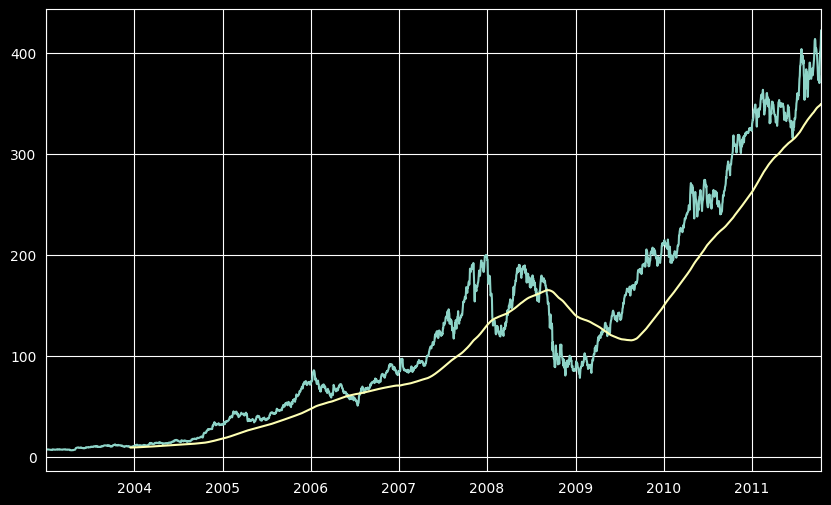

In [103]:
#! ipython id=3a7907583c5c464eb2d146e8ddcb479f
close_px["AAPL"].plot()
#! figure,id=apple_daily_ma250,title="Wykres cen akcji firmy Apple przy 250-dniowej ruchomej średniej"
close_px["AAPL"].rolling(250).mean().plot()

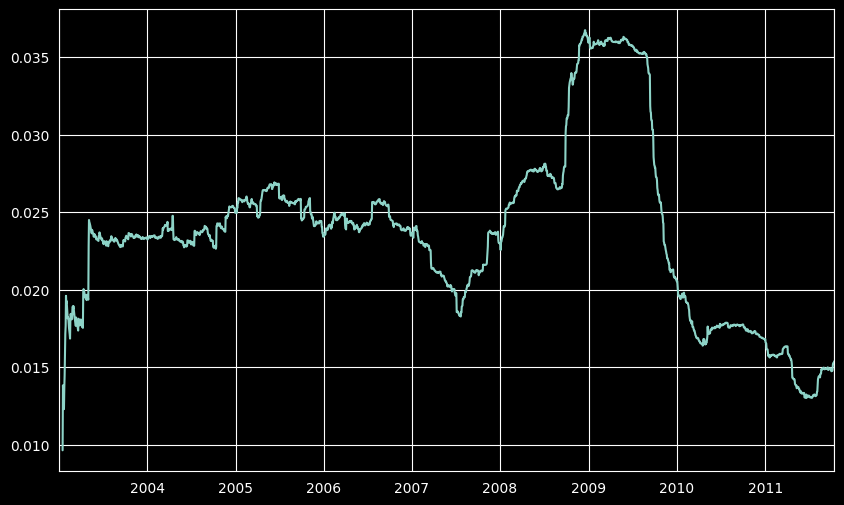

In [104]:
#! ipython id=cd2ea550f4ab44bebddcdef67fc7990b
plt.figure()
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()
std250[5:12]
#! figure,id=apple_daily_std250,title="Akcje firmy Apple - 250-dniowe odchylenie standardowe dziennego zwrotu"
std250.plot()

In [105]:
#! ipython id=504b4010407f4edcac81dfa106681206
expanding_mean = std250.expanding().mean()

In [106]:
#! ipython suppress id=828830f0853b45388516d1d716305702
plt.figure()

<Figure size 1000x600 with 0 Axes>

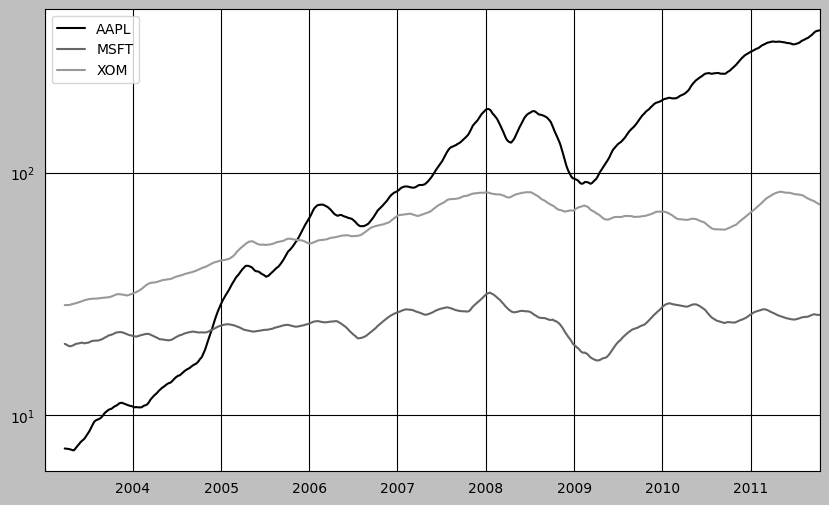

In [107]:
#! ipython id=757ccd62b4c64042add7a055b90d3f79
plt.style.use('grayscale')
#! figure,id=stocks_daily_ma60,title="Sześćdziesięciodniowa średnia ruchoma cen akcji (logarytm osi Y)"
close_px.rolling(60).mean().plot(logy=True)

In [108]:
#! ipython id=d1df05357bef4ef5be80524c35b9407a
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


In [109]:
#! ipython suppress id=f65d7f1f960c4466af77c7e80a9fdf4c
plt.figure()

<Figure size 1000x600 with 0 Axes>

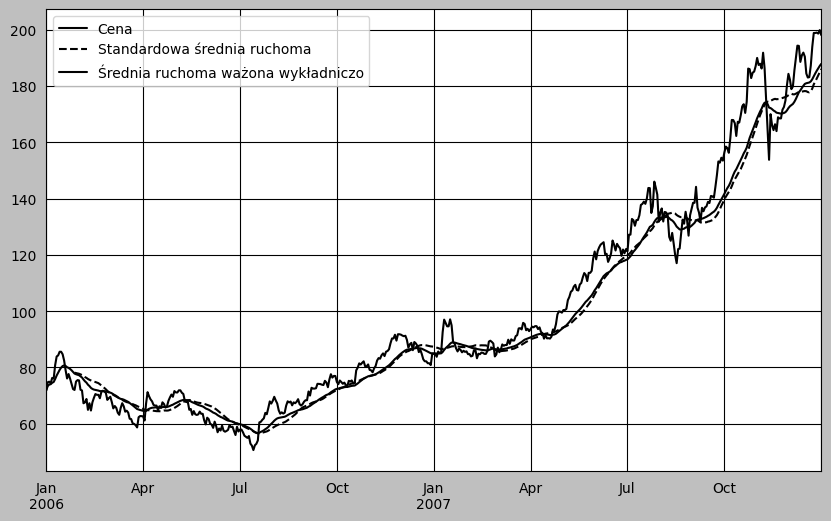

In [110]:
#! ipython id=fac9c661db8a4c77bd6e450f0ca0f082
aapl_px = close_px["AAPL"]["2006":"2007"]

ma30 = aapl_px.rolling(30, min_periods=20).mean()
ewma30 = aapl_px.ewm(span=30).mean()

aapl_px.plot(style="k-", label="Cena")
ma30.plot(style="k--", label="Standardowa średnia ruchoma")
ewma30.plot(style="k-", label="Średnia ruchoma ważona wykładniczo")
#! figure,id=timeseries_ewma,title="Porównanie standardowej średniej ruchomej ze średnią ruchomą ważoną wykładniczo"
plt.legend()

In [111]:
#! ipython suppress id=cf8d4580bade4701b8cc6c1b05c4ed97
plt.figure()

<Figure size 1000x600 with 0 Axes>

In [112]:
#! ipython id=850496d7c94b423f994cbc710002ccf7
spx_px = close_px_all["SPX"]
spx_rets = spx_px.pct_change()
returns = close_px.pct_change()

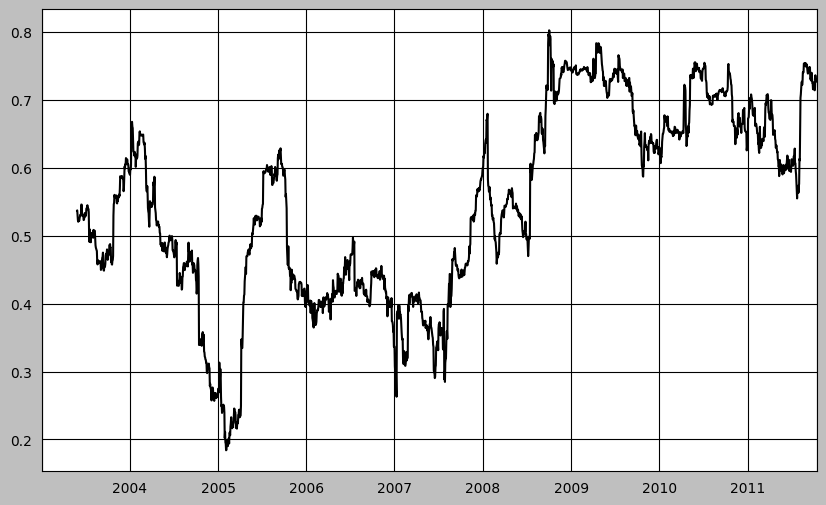

In [113]:
#! ipython id=f065c26f19e7491b8f573f8d0f0d67e3
corr = returns["AAPL"].rolling(125, min_periods=100).corr(spx_rets)
#! figure,id=roll_correl_aapl,title="Korelacja zwrotu (firma Apple) i indeksu S&P 500 na przestrzeni sześciu miesięcy"
corr.plot()

In [114]:
#! ipython suppress id=f67e1433110f4a6a8e72034ead461e09
plt.figure()

<Figure size 1000x600 with 0 Axes>

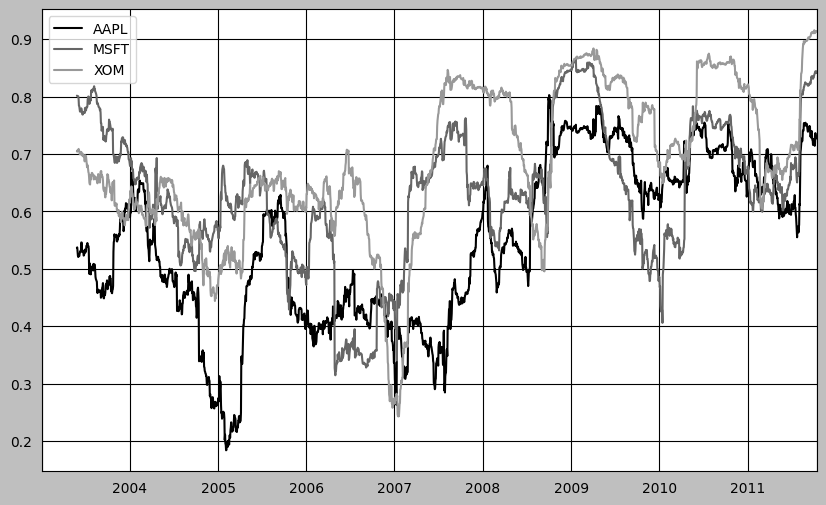

In [115]:
#! ipython id=e312071fe8a74319afc03f447030c468
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
#! figure,id=roll_correl_all,title="Korelacje zwrotów z indeksem S&P 500 na przestrzeni sześciu miesięcy"
corr.plot()

In [116]:
#! ipython suppress id=e0f7372085924896960706add4fa5f56
plt.figure()

<Figure size 1000x600 with 0 Axes>

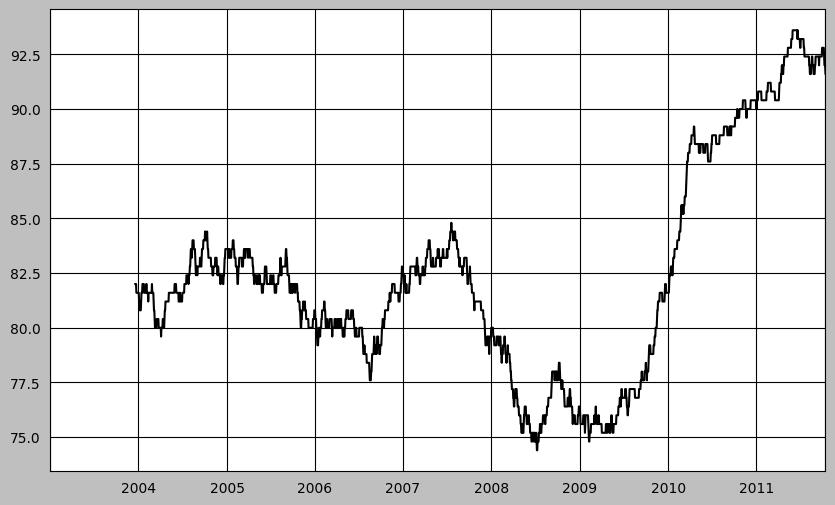

In [117]:
#! ipython id=e176480d4d034f1bbaa1b4c09caf9df6
from scipy.stats import percentileofscore
def score_at_2percent(x):
    return percentileofscore(x, 0.02)

result = returns["AAPL"].rolling(250).apply(score_at_2percent)
#! figure,id=roll_apply_ex,title="Percentyl rangi 2% zwrotu przy rocznym oknie"
result.plot()

In [118]:
#! ipython suppress id=419d9badc37c41888f19b0fd158061dd
%popd

/home/michal/time_series
popd -> ~/time_series


In [119]:
#! ipython suppress id=1ff3016eeceb4d3e9a95f134c7ab9512
pd.options.display.max_rows = PREVIOUS_MAX_ROWS